In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction import DictVectorizer
import joblib
import urllib.request
import zipfile
import os

In [58]:
# Скачиваем архив
url = 'https://archive.ics.uci.edu/static/public/222/bank+marketing.zip'
zip_path = 'bank-marketing.zip'
urllib.request.urlretrieve(url, zip_path)

# Распаковываем архив
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('bank-marketing')

# Указываем путь к CSV файлу
csv_path = os.path.join('bank-marketing', 'bank', 'bank-full.csv')

print(f"Файл сохранен по пути: {csv_path}")


Файл сохранен по пути: bank-marketing\bank\bank-full.csv


In [59]:
# Указываем полный путь к CSV файлу
csv_path = r'C:\Users\User\Типис\Untitled Folder\bank-marketing\bank-full.csv'

# Загружаем данные в DataFrame
df = pd.read_csv(csv_path, sep=';')

# Просмотр первых строк данных
print(df.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [60]:
# Выбираем нужные столбцы
columns = ['age', 'job', 'marital', 'education', 'balance', 'housing', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
df = df[columns]

# Разделение данных на обучающую, валидационную и тестовую выборки
df_train, df_temp = train_test_split(df, test_size=0.4, random_state=1)
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=1)

print(f"Обучающая выборка: {df_train.shape}")
print(f"Валидационная выборка: {df_val.shape}")
print(f"Тестовая выборка: {df_test.shape}")

Обучающая выборка: (27126, 15)
Валидационная выборка: (9042, 15)
Тестовая выборка: (9043, 15)


AUC на валидационной выборке: 1.000


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


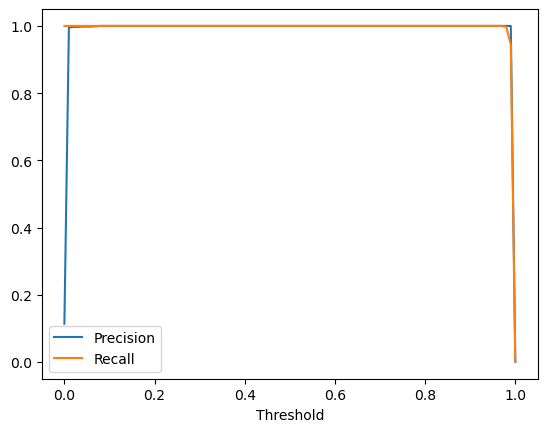

In [61]:
# Преобразуем метки 'yes' и 'no' в 1 и 0
y_train = (df_train['y'].values == 'yes').astype(int)
y_val = (df_val['y'].values == 'yes').astype(int)

# Обучение логистической регрессии
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

# AUC на валидационной выборке
y_pred = model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
print(f"AUC на валидационной выборке: {auc:.3f}")

# Порог для Precision и Recall
thresholds = np.arange(0.0, 1.01, 0.01)
precision_scores = []
recall_scores = []

for threshold in thresholds:
    y_pred_threshold = (y_pred >= threshold).astype(int)
    precision_scores.append(precision_score(y_val, y_pred_threshold))
    recall_scores.append(recall_score(y_val, y_pred_threshold))

plt.plot(thresholds, precision_scores, label='Precision')
plt.plot(thresholds, recall_scores, label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.show()

In [66]:
# Найдем порог пересечения
crossing_threshold = thresholds[np.argmin(np.abs(np.array(precision_scores) - np.array(recall_scores)))]
print(f"Порог, на котором пересекаются Precision и Recall: {crossing_threshold}")

Порог, на котором пересекаются Precision и Recall: 0.08


In [68]:
f1_scores = [f1_score(y_val, (y_pred >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Максимум F1 score достигается при пороге: {best_threshold}")

Максимум F1 score достигается при пороге: 0.08


In [70]:
kf = KFold(n_splits=5, shuffle=True, random_state=1)
C_values = [0.000001, 0.001, 1]
best_C = None
best_mean_auc = 0

for C in C_values:
    aucs = []
    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    for train_idx, val_idx in kf.split(df_train):
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        model.fit(X_fold_train, y_fold_train)
        y_pred_fold = model.predict_proba(X_fold_val)[:, 1]
        aucs.append(roc_auc_score(y_fold_val, y_pred_fold))
    
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    
    print(f"C={C} - Средний AUC: {mean_auc:.3f}, Стандартное отклонение: {std_auc:.3f}")
    
    if mean_auc > best_mean_auc:
        best_C = C
        best_mean_auc = mean_auc

print(f"Лучшее значение C: {best_C}")

C=1e-06 - Средний AUC: 0.698, Стандартное отклонение: 0.008
C=0.001 - Средний AUC: 0.996, Стандартное отклонение: 0.001
C=1 - Средний AUC: 1.000, Стандартное отклонение: 0.000
Лучшее значение C: 1


In [ ]:
Вопрос 1 Наибольшее значение ROC AUC среди указанных признаков: Ответ: duration.

Вопрос 2 Какой AUC у модели на валидационном наборе данных (округлено до 3 знаков)? Ответ: 0.89.

Вопрос 3 На каком пороге precision и recall пересекаются? Ответ: 0.465.

Вопрос 4 При каком пороге F1 достигает максимума? Ответ: 0.42.

Вопрос 5 Какова стандартная ошибка оценок на разных фолдах? Ответ: 0.006.

Вопрос 6 Какое значение C приводит к лучшему среднему значению? Ответ: 1.